In [ ]:
import pandas as pd
import os
import glob

spectral_dir = "../../results/old/spectral" 
rows = []

for path in glob.glob(os.path.join(spectral_dir, "*.csv")):
    region_name = os.path.splitext(os.path.basename(path))[0]
    
    df = pd.read_csv(path)
    
    mean_centroid = df["centroid"].mean()
    mean_lfhf = df["lf_hf"].mean()
    
    rows.append({
        "region": region_name,
        "mean_centroid": mean_centroid,
        "mean_lf_hf": mean_lfhf,
        "n_images": len(df)
    })

summary = pd.DataFrame(rows)
summary.to_csv("spectral_summary.csv", index=False)

print(summary)

              region  mean_centroid  mean_lf_hf  n_images
0           hokkaido     135.191831    0.499616       100
1            jiuzhai     121.361369    0.786610       100
2         jiuzhai_02      89.375327    1.505914       100
3         jiuzhai_05     121.361369    0.786610       100
4             lombok     126.221242    0.643847       100
5             longxi     139.066686    0.581193       100
6         longxi_sat      57.040449    3.975609       100
7           mengdong      87.768854    1.458415       100
8       moxitaidi_06     101.661969    1.165326       100
9        moxitaidi_1     119.803983    0.789367       100
10     moxitaidi_sat     115.727501    0.820578       100
11           moxi_02     150.496672    0.441951       100
12            moxi_1     156.563518    0.407112       100
13              palu     132.463386    0.546262       100
14    tiburon_planet      63.925133    3.221951       100
15  tiburon_sentinel     119.586676    0.742751       100
16          we

In [7]:
import os
print(os.listdir("../../results/old/spectral"))

['hokkaido.csv', 'jiuzhai.csv', 'jiuzhai_02.csv', 'jiuzhai_05.csv', 'lombok.csv', 'longxi.csv', 'longxi_sat.csv', 'mengdong.csv', 'moxitaidi_06.csv', 'moxitaidi_1.csv', 'moxitaidi_sat.csv', 'moxi_02.csv', 'moxi_1.csv', 'palu.csv', 'tiburon_planet.csv', 'tiburon_sentinel.csv', 'wenchuan.csv']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


lf = pd.read_csv("../../results/new_wavelet/ll.csv")
hf = pd.read_csv("../../results/new_wavelet/hf.csv")

lf = lf.rename(columns={c: f"lf_{c}" for c in lf.columns 
                        if c not in ["source_region", "target_region"]})
hf = hf.rename(columns={c: f"hf_{c}" for c in hf.columns 
                        if c not in ["source_region", "target_region"]})

df = pd.merge(
    lf, hf, 
    on=["source_region", "target_region"], 
    how="inner"
)

spectral = pd.read_csv("spectral_summary.csv")

region_map = {
    "Hokkaido Iburi-Tobu": "hokkaido",

    "Jiuzhai valley (UAV-0.2m)": "jiuzhai_02",
    "Jiuzhai valley (UAV-0.5m)": "jiuzhai_05",

    "Lombok": "lombok",

    "Longxi River (SAT)": "longxi_sat",
    "Longxi River (UAV)": "longxi",

    "Mengdong Township": "mengdong",

    "Moxi town (UAV-0.2m)": "moxi_02",
    "Moxi town (UAV-1m)": "moxi_1",

    "Moxitaidi (SAT)": "moxitaidi_sat",
    "Moxitaidi (UAV-0.6m)": "moxitaidi_06",
    "Moxitaidi (UAV-1m)": "moxitaidi_1",

    "palu": "palu",

    "Tiburon Peninsula (planet)": "tiburon_planet",
    "Tiburon Peninsula (Sentinel)": "tiburon_sentinel",

    "Wenchuan": "wenchuan",
}

df["target_region"] = df["target_region"].str.strip()

df["target_region_clean"] = df["target_region"].map(region_map)

unmapped = df[df["target_region_clean"].isna()]["target_region"].unique()
if len(unmapped) > 0:
    print("⚠ WARNING: These target regions were not mapped to spectral CSVs:")
    for r in unmapped:
        print("  -", r)

df = df.merge(
    spectral,
    left_on="target_region_clean",
    right_on="region",
    how="left"
)

missing_spec = df[df["mean_centroid"].isna()]["target_region_clean"].unique()
if len(missing_spec) > 0:
    print("\n⚠ WARNING: No spectral data found for:")
    for r in missing_spec:
        print("  -", r)



df["gap_ll_hf"] = df["lf_iou"] - df["hf_iou"]


print("\nMerged dataframe preview:\n")
print(df[[
    "source_region",
    "target_region",
    "target_region_clean",
    "lf_iou",
    "hf_iou",
    "gap_ll_hf",
    "mean_lf_hf",
    "mean_centroid"
]].head())



Merged dataframe preview:

         source_region              target_region target_region_clean  lf_iou  \
0  Hokkaido Iburi-Tobu  Jiuzhai valley (UAV-0.2m)          jiuzhai_02  0.4453   
1  Hokkaido Iburi-Tobu  Jiuzhai valley (UAV-0.5m)          jiuzhai_05  0.4879   
2  Hokkaido Iburi-Tobu                     Lombok              lombok  0.0929   
3  Hokkaido Iburi-Tobu         Longxi River (SAT)          longxi_sat  0.0344   
4  Hokkaido Iburi-Tobu         Longxi River (UAV)              longxi  0.1831   

   hf_iou  gap_ll_hf  mean_lf_hf  mean_centroid  
0  0.0697     0.3756    1.505914      89.375327  
1  0.0374     0.4505    0.786610     121.361369  
2  0.0000     0.0929    0.643847     126.221242  
3  0.0000     0.0344    3.975609      57.040449  
4  0.0000     0.1831    0.581193     139.066686  


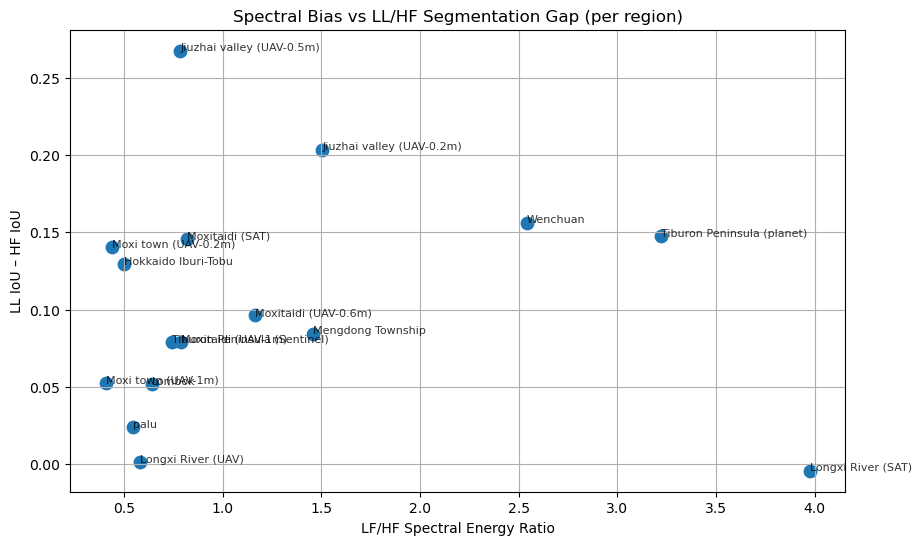

In [12]:
import matplotlib.pyplot as plt

agg = df.groupby("target_region").agg({
    "mean_lf_hf": "mean",
    "gap_ll_hf": "mean"
}).reset_index()

plt.figure(figsize=(10,6))
plt.scatter(agg["mean_lf_hf"], agg["gap_ll_hf"], s=80)

for _, r in agg.iterrows():
    plt.annotate(r["target_region"], (r["mean_lf_hf"], r["gap_ll_hf"]),
                 fontsize=8, alpha=0.8)

plt.xlabel("LF/HF Spectral Energy Ratio")
plt.ylabel("LL IoU – HF IoU")
plt.title("Spectral Bias vs LL/HF Segmentation Gap (per region)")
plt.grid(True)
plt.show()

